In [1]:
# ═══════════════════════════════════════════════════════
# NEPALI OCR — CRNN + CTC Word Recognition
# Model: CNN + BiLSTM + CTC Loss
# No segmentation needed — reads full words directly
# ═══════════════════════════════════════════════════════

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image, ImageDraw, ImageFont
import random
import os

device = torch.device('cpu')
torch.set_num_threads(6)

prop = fm.FontProperties(
    fname='/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf')

# ── Character vocabulary ──────────────────────────────
# All Nepali characters + special tokens
CHARS = ['<blank>',  # CTC blank token — index 0
         'क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
         'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
         'प','फ','ब','भ','म','य','र','ल','व','श',
         'ष','स','ह','क्ष','त्र','ज्ञ',
         '०','१','२','३','४','५','६','७','८','९',
         'ा','ि','ी','ु','ू','े','ै','ो','ौ','ं','ः','्']

char2idx = {c: i for i, c in enumerate(CHARS)}
idx2char = {i: c for i, c in enumerate(CHARS)}

print("Vocabulary size:", len(CHARS))
print("Device:", device)
print("Sample chars:", CHARS[1:10])

Vocabulary size: 59
Device: cpu
Sample chars: ['क', 'ख', 'ग', 'घ', 'ङ', 'च', 'छ', 'ज', 'झ']


/tmp/ipykernel_30174/4001427856.py:46: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/4001427856.py:46: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)


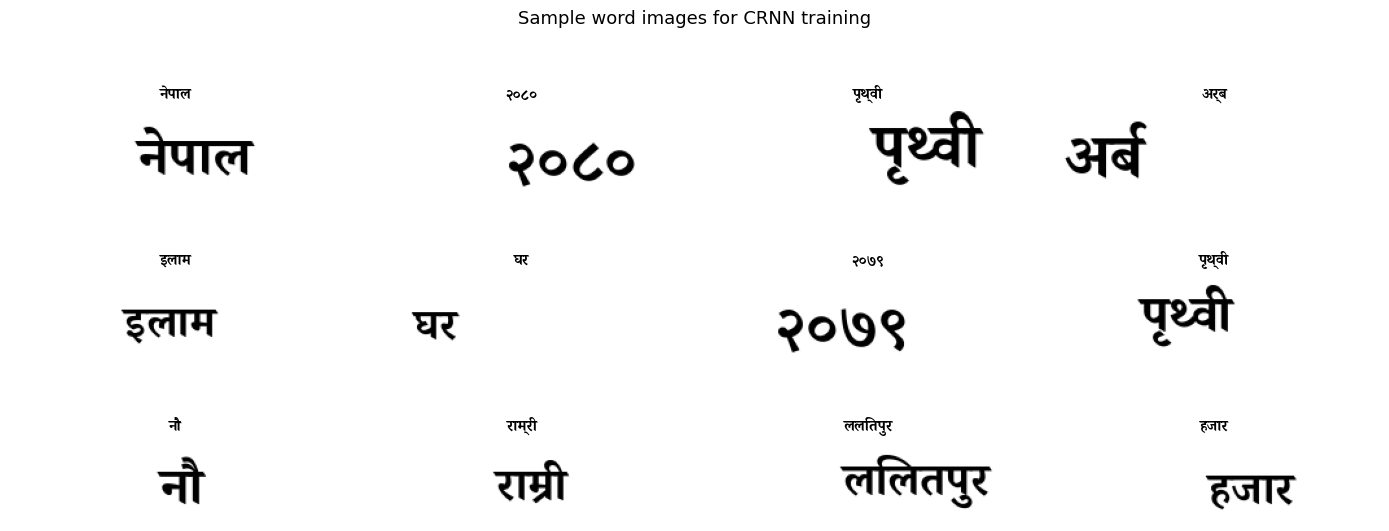

Word image generation working!
Total words in vocabulary: 80


In [2]:
# ── Synthetic word dataset generator ─────────────────────────
FONT_PATH = '/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf'

# Common Nepali words for training
NEPALI_WORDS = [
    'नेपाल', 'काठमाडौं', 'पोखरा', 'जनकपुर', 'भक्तपुर',
    'ललितपुर', 'बिराटनगर', 'धरान', 'इटहरी', 'बुटवल',
    'नारायणगढ', 'हेटौडा', 'दमक', 'इलाम', 'तापलेजुङ',
    'नमस्ते', 'धन्यवाद', 'शुभकामना', 'स्वागत', 'बिदाई',
    'राम्रो', 'राम्री', 'राम्रा', 'सुन्दर', 'अग्लो',
    'पानी', 'खाना', 'घर', 'ढोका', 'झ्याल',
    'किताब', 'कलम', 'कापी', 'थैला', 'जुत्ता',
    'आमा', 'बुवा', 'दाई', 'दिदी', 'भाई',
    'बहिनी', 'साथी', 'शिक्षक', 'विद्यार्थी', 'विद्यालय',
    'सूर्य', 'चन्द्र', 'तारा', 'आकाश', 'पृथ्वी',
    'नदी', 'पहाड', 'जंगल', 'बाटो', 'खेत',
    'गाई', 'भैंसी', 'बाख्रा', 'कुकुर', 'बिरालो',
    'एक', 'दुई', 'तीन', 'चार', 'पाँच',
    'छ', 'सात', 'आठ', 'नौ', 'दस',
    'सय', 'हजार', 'लाख', 'करोड', 'अर्ब',
    '२०८१', '२०८०', '२०७९', '१२३४', '५६७८',
]

def generate_word_image(word, font_path=FONT_PATH, img_h=64, img_w=256):
    font_size = random.randint(32, 48)
    font      = ImageFont.truetype(font_path, size=font_size)
    img       = Image.new('L', (img_w, img_h), color=255)
    draw      = ImageDraw.Draw(img)
    bbox      = draw.textbbox((0, 0), word, font=font)
    w         = bbox[2] - bbox[0]
    h         = bbox[3] - bbox[1]
    x         = random.randint(5, max(6, img_w - w - 5))
    y         = (img_h - h) // 2
    draw.text((x, y), word, font=font, fill=0)
    return img

# Test generation
fig, axes = plt.subplots(3, 4, figsize=(14, 6))
for ax in axes.flat:
    word = random.choice(NEPALI_WORDS)
    img  = generate_word_image(word)
    ax.imshow(img, cmap='gray')
    ax.set_title(word, fontproperties=prop, fontsize=11)
    ax.axis('off')
plt.suptitle('Sample word images for CRNN training', fontsize=13)
plt.tight_layout()
plt.show()
print("Word image generation working!")
print(f"Total words in vocabulary: {len(NEPALI_WORDS)}")

In [3]:
# ── CRNN Dataset ──────────────────────────────────────────────
class CRNNDataset(Dataset):
    def __init__(self, words, n_samples=10000, img_h=64, img_w=256):
        self.words    = words
        self.n        = n_samples
        self.img_h    = img_h
        self.img_w    = img_w
        self.transform = T.Compose([
            T.ToTensor(),
            T.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        word = random.choice(self.words)
        img  = generate_word_image(word, img_h=self.img_h, img_w=self.img_w)
        img  = self.transform(img)           # (1, H, W)

        # Encode label — character by character
        label = []
        for ch in word:
            if ch in char2idx:
                label.append(char2idx[ch])
        label = torch.tensor(label, dtype=torch.long)
        return img, label, len(label)

def collate_fn(batch):
    imgs, labels, lengths = zip(*batch)
    imgs    = torch.stack(imgs)
    lengths = torch.tensor(lengths, dtype=torch.long)
    # Pad labels to same length
    max_len     = max(len(l) for l in labels)
    padded      = torch.zeros(len(labels), max_len, dtype=torch.long)
    for i, l in enumerate(labels):
        padded[i, :len(l)] = l
    return imgs, padded, lengths

# Create datasets
train_ds = CRNNDataset(NEPALI_WORDS, n_samples=8000)
val_ds   = CRNNDataset(NEPALI_WORDS, n_samples=1000)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

# Quick check
imgs, labels, lengths = next(iter(train_loader))
print("Batch image shape:", imgs.shape)    # (32, 1, 64, 256)
print("Batch label shape:", labels.shape)  # (32, max_label_len)
print("Lengths:", lengths[:5].tolist())

Batch image shape: torch.Size([32, 1, 64, 256])
Batch label shape: torch.Size([32, 8])
Lengths: [3, 7, 2, 8, 6]


In [4]:
# ── CRNN Model — CNN + BiLSTM + CTC ──────────────────────────
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # CNN — extract visual features
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 64x128
            # Block 2
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 32x64 → 16x64
            # Block 3
            nn.Conv2d(128, 256, 3, padding=1),nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d((2,1)),              # 8x64
            # Block 4
            nn.Conv2d(256, 512, 3, padding=1),nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d((2,1)),              # 4x64
            # Block 5
            nn.Conv2d(512, 512, 3, padding=1),nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d((2,1)),              # 2x64
        )
        
        # BiLSTM — read sequence left to right
        self.rnn = nn.LSTM(
            input_size=512 * 2,   # 512 channels * 2 height rows
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )
        
        # Output layer
        self.fc = nn.Linear(512, num_classes)  # 256*2 bidirectional

    def forward(self, x):
        # CNN features
        x = self.cnn(x)                          # (B, C, H, W)
        b, c, h, w = x.size()
        
        # Reshape for RNN — treat width as time steps
        x = x.permute(0, 3, 1, 2)               # (B, W, C, H)
        x = x.reshape(b, w, c * h)              # (B, W, C*H)
        
        # BiLSTM
        x, _ = self.rnn(x)                       # (B, W, 512)
        
        # Output
        x = self.fc(x)                           # (B, W, num_classes)
        return x.log_softmax(2)                  # CTC expects log softmax

# Build model
model = CRNN(num_classes=len(CHARS)).to(device)

# Test with dummy input
dummy = torch.zeros(4, 1, 64, 256).to(device)
out   = model(dummy)
print("Output shape:", out.shape)   # should be (4, 64, 59)
print("Num classes:", len(CHARS))
print("CRNN model ready!")

Output shape: torch.Size([4, 64, 59])
Num classes: 59
CRNN model ready!


In [5]:
# ── CTC Training Loop ─────────────────────────────────────────
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 20

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_loss = 0

    for imgs, labels, lengths in train_loader:
        imgs    = imgs.to(device)
        labels  = labels.to(device)

        optimizer.zero_grad()
        out = model(imgs)                          # (B, W, C)

        # CTC needs (T, B, C)
        out_ctc     = out.permute(1, 0, 2)        # (W, B, C)
        input_lens  = torch.full((imgs.size(0),), out.size(1), dtype=torch.long)

        # Flatten labels — remove padding
        flat_labels = []
        flat_lens   = []
        for i in range(labels.size(0)):
            l = labels[i][:lengths[i]]
            flat_labels.append(l)
            flat_lens.append(lengths[i].item())

        flat_labels = torch.cat(flat_labels)
        flat_lens   = torch.tensor(flat_lens, dtype=torch.long)

        loss = criterion(out_ctc, flat_labels, input_lens, flat_lens)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    scheduler.step()
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f}")

print("\nTraining complete!")
torch.save(model.state_dict(), '/home/kulraj/nepali_ocr/models/crnn_nepali.pth')
print("Saved to models/crnn_nepali.pth")

Epoch 01/20 | Loss: 4.2878
Epoch 02/20 | Loss: 2.5571
Epoch 03/20 | Loss: 0.7580
Epoch 04/20 | Loss: 0.0671
Epoch 05/20 | Loss: 0.0120
Epoch 06/20 | Loss: 0.0053
Epoch 07/20 | Loss: 0.0037
Epoch 08/20 | Loss: 0.0027
Epoch 09/20 | Loss: 0.0022
Epoch 10/20 | Loss: 0.0192
Epoch 11/20 | Loss: 0.0116
Epoch 12/20 | Loss: 0.0031
Epoch 13/20 | Loss: 0.0022
Epoch 14/20 | Loss: 0.0018
Epoch 15/20 | Loss: 0.0014
Epoch 16/20 | Loss: 0.0012
Epoch 17/20 | Loss: 0.0011
Epoch 18/20 | Loss: 0.0010
Epoch 19/20 | Loss: 0.0010
Epoch 20/20 | Loss: 0.0009

Training complete!
Saved to models/crnn_nepali.pth


CRNN Predictions:
──────────────────────────────────────────────────
✓ True: नेपाल           | Pred: नेपाल
✓ True: काठमाडौं        | Pred: काठमाडौं
✓ True: नमस्ते          | Pred: नमस्ते
✓ True: धन्यवाद         | Pred: धन्यवाद
✓ True: पोखरा           | Pred: पोखरा
✓ True: २०८१            | Pred: २०८१
✗ True: आमा             | Pred: मा
✓ True: बुवा            | Pred: बुवा
✓ True: किताब           | Pred: किताब
✓ True: पानी            | Pred: पानी


/tmp/ipykernel_30174/616498403.py:45: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/616498403.py:45: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/616498403.py:45: UserWarning: Glyph 84 (T) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/616498403.py:45: UserWarning: Glyph 80 (P) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 84 (T) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 80 (P) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)


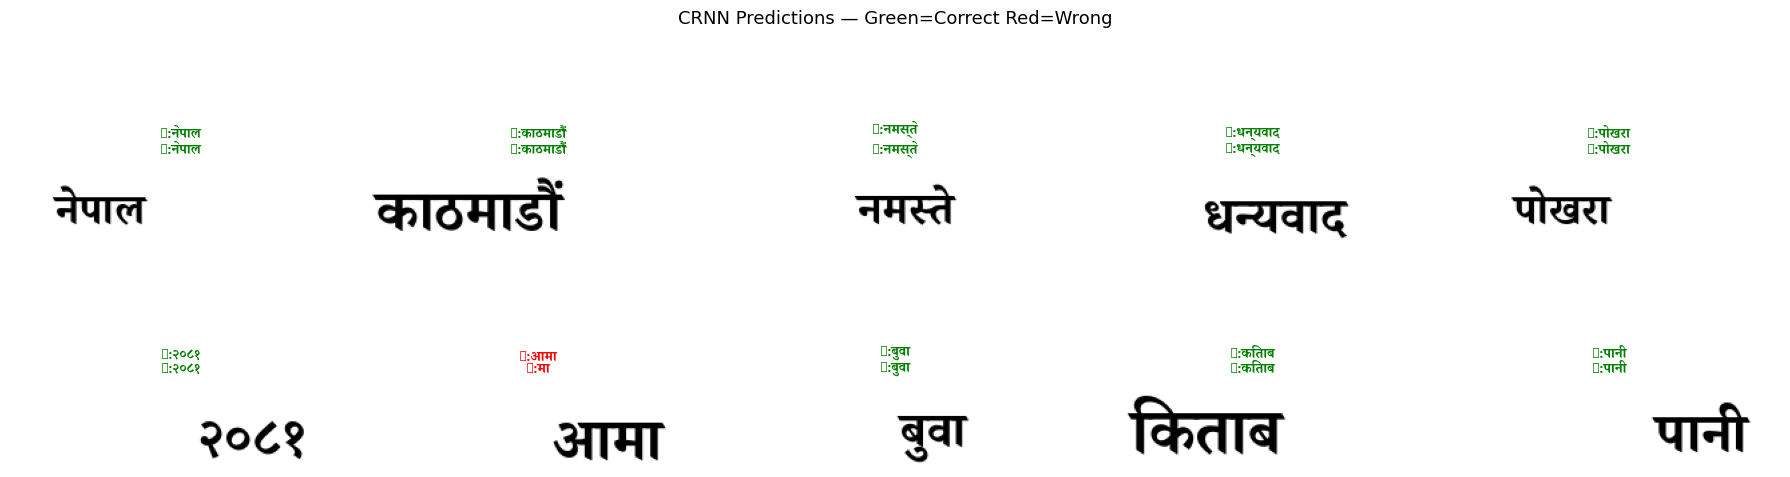

In [6]:
# ── CTC Greedy Decoder ────────────────────────────────────────
def ctc_decode(output, idx2char):
    # output: (W, num_classes)
    pred_ids = output.argmax(1).tolist()
    
    # Collapse repeats and remove blank (index 0)
    chars  = []
    prev   = -1
    for idx in pred_ids:
        if idx != prev and idx != 0:
            chars.append(idx2char[idx])
        prev = idx
    return ''.join(chars)

# ── Test on sample words ──────────────────────────────────────
model.eval()
test_words = ['नेपाल', 'काठमाडौं', 'नमस्ते', 'धन्यवाद', 'पोखरा',
              '२०८१', 'आमा', 'बुवा', 'किताब', 'पानी']

print("CRNN Predictions:")
print("─" * 50)

fig, axes = plt.subplots(2, 5, figsize=(18, 6))

for i, word in enumerate(test_words):
    img     = generate_word_image(word)
    img_t   = T.ToTensor()(img)
    img_t   = T.Normalize((0.5,), (0.5,))(img_t)
    img_t   = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        out  = model(img_t)               # (1, W, C)
        pred = ctc_decode(out[0], idx2char)

    correct = "✓" if pred == word else "✗"
    print(f"{correct} True: {word:15s} | Pred: {pred}")

    axes[i//5][i%5].imshow(img, cmap='gray')
    color = 'green' if pred == word else 'red'
    axes[i//5][i%5].set_title(f"T:{word}\nP:{pred}",
                               fontproperties=prop, fontsize=10, color=color)
    axes[i//5][i%5].axis('off')

plt.suptitle('CRNN Predictions — Green=Correct Red=Wrong', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# ── Check missing characters ──────────────────────────────────
test_missing = ['आमा', 'ईश्वर', 'उहाँ', 'ओखर', 'औषधि']

for word in test_missing:
    missing = [ch for ch in word if ch not in char2idx]
    print(f"{word} → missing chars: {missing}")

आमा → missing chars: ['आ']
ईश्वर → missing chars: ['ई']
उहाँ → missing chars: ['उ', 'ँ']
ओखर → missing chars: ['ओ']
औषधि → missing chars: ['औ']


In [8]:
# ── Extended vocabulary with all Nepali vowels ────────────────
CHARS = ['<blank>',
         # Consonants
         'क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
         'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
         'प','फ','ब','भ','म','य','र','ल','व','श',
         'ष','स','ह','क्ष','त्र','ज्ञ',
         # Digits
         '०','१','२','३','४','५','६','७','८','९',
         # Dependent vowel signs (matras)
         'ा','ि','ी','ु','ू','े','ै','ो','ौ','ं','ः','्','ँ',
         # Independent vowels
         'अ','आ','इ','ई','उ','ऊ','ए','ऐ','ओ','औ','अं','अः',
         ]

char2idx = {c: i for i, c in enumerate(CHARS)}
idx2char = {i: c for i, c in enumerate(CHARS)}

print("Extended vocabulary size:", len(CHARS))

# Verify आमा is now encodable
test_word = 'आमा'
encoded   = [char2idx.get(ch, -1) for ch in test_word]
print(f"आमा encoded: {encoded}")
print(f"Missing: {[ch for ch in test_word if ch not in char2idx]}")

Extended vocabulary size: 72
आमा encoded: [61, 25, 47]
Missing: []


In [9]:
# ── Rebuild dataset and retrain with extended vocabulary ──────

# Extended word list including words with vowels
NEPALI_WORDS_EXT = NEPALI_WORDS + [
    'आमा', 'आकाश', 'आगो', 'आँखा', 'आफू',
    'इनार', 'इच्छा', 'ईश्वर', 'ईमान',
    'उखु', 'उकाली', 'ऊन', 'ऊँट',
    'एक', 'एकता', 'ऐना', 'ऐतिहासिक',
    'ओखर', 'ओठ', 'औषधि', 'औजार',
    'अमिलो', 'अनार', 'अगाडि', 'अपाङ',
]

print(f"Total words: {len(NEPALI_WORDS_EXT)}")

# Verify all words are encodable
for word in NEPALI_WORDS_EXT:
    missing = [ch for ch in word if ch not in char2idx]
    if missing:
        print(f"Still missing in {word}: {missing}")

print("All words encodable!")

# Rebuild datasets
train_ds2 = CRNNDataset(NEPALI_WORDS_EXT, n_samples=8000)
val_ds2   = CRNNDataset(NEPALI_WORDS_EXT, n_samples=1000)

train_loader2 = DataLoader(train_ds2, batch_size=32, shuffle=True,
                           collate_fn=collate_fn, num_workers=0)
val_loader2   = DataLoader(val_ds2,   batch_size=32, shuffle=False,
                           collate_fn=collate_fn, num_workers=0)

# Retrain with new vocabulary
model2    = CRNN(num_classes=len(CHARS)).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 20
for epoch in range(EPOCHS):
    model2.train()
    total_loss = 0

    for imgs, labels, lengths in train_loader2:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        out        = model2(imgs)
        out_ctc    = out.permute(1, 0, 2)
        input_lens = torch.full((imgs.size(0),), out.size(1), dtype=torch.long)

        flat_labels = []
        flat_lens   = []
        for i in range(labels.size(0)):
            l = labels[i][:lengths[i]]
            flat_labels.append(l)
            flat_lens.append(lengths[i].item())

        flat_labels = torch.cat(flat_labels)
        flat_lens   = torch.tensor(flat_lens, dtype=torch.long)

        loss = criterion(out_ctc, flat_labels, input_lens, flat_lens)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model2.parameters(), 5)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {total_loss/len(train_loader2):.4f}")

print("\nDone! Saving...")
torch.save(model2.state_dict(), '/home/kulraj/nepali_ocr/models/crnn_nepali_v2.pth')
print("Saved to models/crnn_nepali_v2.pth")

Total words: 105
Still missing in पृथ्वी: ['ृ']
All words encodable!
Epoch 01/20 | Loss: 4.3384
Epoch 02/20 | Loss: 2.0668
Epoch 03/20 | Loss: 0.3057
Epoch 04/20 | Loss: 0.0239
Epoch 05/20 | Loss: 0.0068
Epoch 06/20 | Loss: 0.0036
Epoch 07/20 | Loss: 0.0028
Epoch 08/20 | Loss: 0.0021
Epoch 09/20 | Loss: 0.0016
Epoch 10/20 | Loss: 0.0013
Epoch 11/20 | Loss: 0.0011
Epoch 12/20 | Loss: 0.0010
Epoch 13/20 | Loss: 0.0009
Epoch 14/20 | Loss: 0.0047
Epoch 15/20 | Loss: 0.0095
Epoch 16/20 | Loss: 0.0013
Epoch 17/20 | Loss: 0.0011
Epoch 18/20 | Loss: 0.0009
Epoch 19/20 | Loss: 0.0008
Epoch 20/20 | Loss: 0.0007

Done! Saving...
Saved to models/crnn_nepali_v2.pth


In [10]:
# ── Add missing ृ and rebuild ─────────────────────────────────
CHARS = ['<blank>',
         # Consonants
         'क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
         'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
         'प','फ','ब','भ','म','य','र','ल','व','श',
         'ष','स','ह','क्ष','त्र','ज्ञ',
         # Digits
         '०','१','२','३','४','५','६','७','८','९',
         # Dependent vowel signs (matras)
         'ा','ि','ी','ु','ू','े','ै','ो','ौ','ं','ः','्','ँ','ृ',
         # Independent vowels
         'अ','आ','इ','ई','उ','ऊ','ए','ऐ','ओ','औ','अं','अः',
         ]

char2idx = {c: i for i, c in enumerate(CHARS)}
idx2char = {i: c for i, c in enumerate(CHARS)}

print("Final vocabulary size:", len(CHARS))

# Verify all words encodable
all_ok = True
for word in NEPALI_WORDS_EXT:
    missing = [ch for ch in word if ch not in char2idx]
    if missing:
        print(f"Missing in {word}: {missing}")
        all_ok = False

if all_ok:
    print("All words encodable!")

Final vocabulary size: 73
All words encodable!


CRNN v2 Predictions:
──────────────────────────────────────────────────
✓ True: नेपाल           | Pred: नेपाल
✓ True: काठमाडौं        | Pred: काठमाडौं
✓ True: नमस्ते          | Pred: नमस्ते
✓ True: धन्यवाद         | Pred: धन्यवाद
✗ True: आमा             | Pred: अमा
✗ True: आकाश            | Pred: अकाश
✗ True: ईश्वर           | Pred: इश्वर
✗ True: उहाँ            | Pred: ृरौ
✗ True: ओखर             | Pred: ऐखर
✗ True: औषधि            | Pred: ओषधि
✓ True: २०८१            | Pred: २०८१
✓ True: किताब           | Pred: किताब


/tmp/ipykernel_30174/3797824290.py:43: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/3797824290.py:43: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/3797824290.py:43: UserWarning: Glyph 84 (T) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/3797824290.py:43: UserWarning: Glyph 80 (P) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()


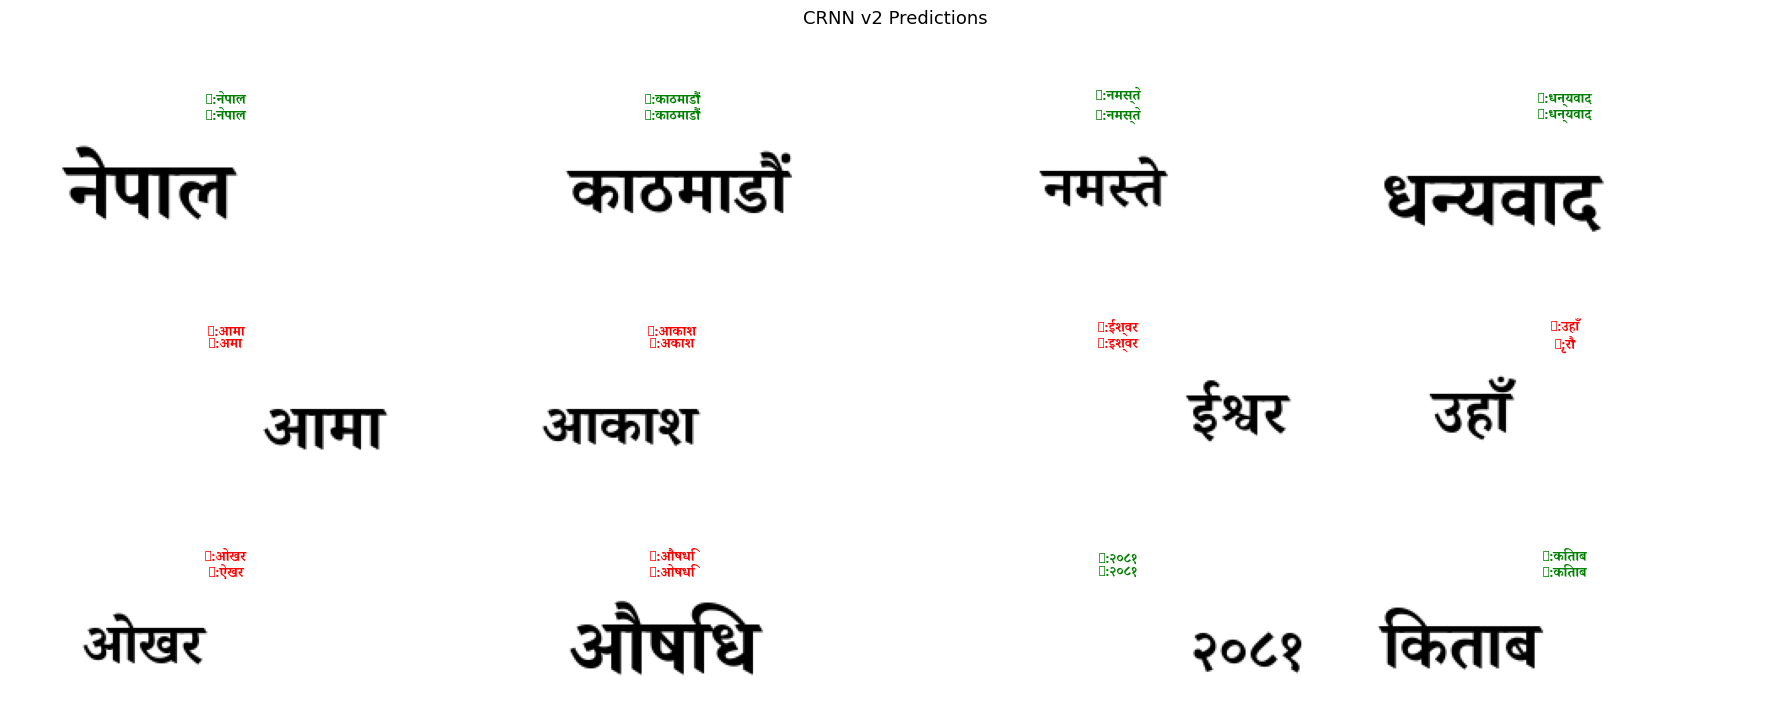


Accuracy: 6/12


In [11]:
# ── Test CRNN v2 with extended vocabulary ─────────────────────
model2.eval()

test_words = ['नेपाल', 'काठमाडौं', 'नमस्ते', 'धन्यवाद',
              'आमा', 'आकाश', 'ईश्वर', 'उहाँ',
              'ओखर', 'औषधि', '२०८१', 'किताब']

print("CRNN v2 Predictions:")
print("─" * 50)

correct_count = 0
fig, axes = plt.subplots(3, 4, figsize=(18, 8))

for i, word in enumerate(test_words):
    # Skip words with missing chars
    missing = [ch for ch in word if ch not in char2idx]
    if missing:
        print(f"⚠ Skipping {word} — missing: {missing}")
        continue

    img   = generate_word_image(word)
    img_t = T.ToTensor()(img)
    img_t = T.Normalize((0.5,), (0.5,))(img_t)
    img_t = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        out  = model2(img_t)
        pred = ctc_decode(out[0], idx2char)

    correct = pred == word
    if correct:
        correct_count += 1
    symbol = "✓" if correct else "✗"
    print(f"{symbol} True: {word:15s} | Pred: {pred}")

    color = 'green' if correct else 'red'
    axes[i//4][i%4].imshow(img, cmap='gray')
    axes[i//4][i%4].set_title(f"T:{word}\nP:{pred}",
                               fontproperties=prop, fontsize=10, color=color)
    axes[i//4][i%4].axis('off')

plt.suptitle('CRNN v2 Predictions', fontsize=13)
plt.tight_layout()
plt.show()
print(f"\nAccuracy: {correct_count}/{len(test_words)}")

In [12]:
# ── Add more vowel-starting words and retrain ─────────────────
VOWEL_WORDS = [
    # आ words
    'आमा', 'आकाश', 'आगो', 'आँखा', 'आफू', 'आज', 'आउनु',
    'आधार', 'आनन्द', 'आराम', 'आवाज', 'आशा', 'आदर',
    # इ/ई words  
    'इनार', 'इच्छा', 'इतिहास', 'ईश्वर', 'ईमान', 'ईर्ष्या',
    # उ/ऊ words
    'उखु', 'उकाली', 'उपाय', 'उत्सव', 'ऊन', 'ऊर्जा',
    # ए/ऐ words
    'एक', 'एकता', 'एकान्त', 'ऐना', 'ऐतिहासिक',
    # ओ/औ words
    'ओखर', 'ओठ', 'ओढ्नु', 'औषधि', 'औजार', 'औचित्य',
    # अ words
    'अमिलो', 'अनार', 'अगाडि', 'अपाङ', 'अभाव', 'अचम्म',
]

NEPALI_WORDS_V2 = NEPALI_WORDS_EXT + VOWEL_WORDS

# Verify all encodable
all_ok = True
for word in NEPALI_WORDS_V2:
    missing = [ch for ch in word if ch not in char2idx]
    if missing:
        print(f"Missing in {word}: {missing}")
        all_ok = False

print(f"Total words: {len(NEPALI_WORDS_V2)}")
if all_ok:
    print("All encodable!")

# Retrain
train_ds3 = CRNNDataset(NEPALI_WORDS_V2, n_samples=10000)
val_ds3   = CRNNDataset(NEPALI_WORDS_V2, n_samples=1000)

train_loader3 = DataLoader(train_ds3, batch_size=32, shuffle=True,
                           collate_fn=collate_fn, num_workers=0)

model3    = CRNN(num_classes=len(CHARS)).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.Adam(model3.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 20
for epoch in range(EPOCHS):
    model3.train()
    total_loss = 0
    for imgs, labels, lengths in train_loader3:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        out        = model3(imgs)
        out_ctc    = out.permute(1, 0, 2)
        input_lens = torch.full((imgs.size(0),), out.size(1), dtype=torch.long)
        flat_labels = []
        flat_lens   = []
        for i in range(labels.size(0)):
            l = labels[i][:lengths[i]]
            flat_labels.append(l)
            flat_lens.append(lengths[i].item())
        flat_labels = torch.cat(flat_labels)
        flat_lens   = torch.tensor(flat_lens, dtype=torch.long)
        loss = criterion(out_ctc, flat_labels, input_lens, flat_lens)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model3.parameters(), 5)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {total_loss/len(train_loader3):.4f}")

print("\nSaving...")
torch.save(model3.state_dict(), '/home/kulraj/nepali_ocr/models/crnn_nepali_v3.pth')
print("Saved to models/crnn_nepali_v3.pth")

Total words: 147
All encodable!
Epoch 01/20 | Loss: 4.1988
Epoch 02/20 | Loss: 2.0855
Epoch 03/20 | Loss: 0.5169
Epoch 04/20 | Loss: 0.0616
Epoch 05/20 | Loss: 0.0129
Epoch 06/20 | Loss: 0.0062
Epoch 07/20 | Loss: 0.0046
Epoch 08/20 | Loss: 0.0033
Epoch 09/20 | Loss: 0.0024
Epoch 10/20 | Loss: 0.0017
Epoch 11/20 | Loss: 0.0015
Epoch 12/20 | Loss: 0.0013
Epoch 13/20 | Loss: 0.0011
Epoch 14/20 | Loss: 0.0010
Epoch 15/20 | Loss: 0.0009
Epoch 16/20 | Loss: 0.0007
Epoch 17/20 | Loss: 0.0007
Epoch 18/20 | Loss: 0.0006
Epoch 19/20 | Loss: 0.0006
Epoch 20/20 | Loss: 0.0005

Saving...
Saved to models/crnn_nepali_v3.pth


CRNN v3 Predictions:
──────────────────────────────────────────────────
✓ True: नेपाल           | Pred: नेपाल
✓ True: काठमाडौं        | Pred: काठमाडौं
✓ True: नमस्ते          | Pred: नमस्ते
✓ True: धन्यवाद         | Pred: धन्यवाद
✓ True: आमा             | Pred: आमा
✓ True: आकाश            | Pred: आकाश
✓ True: ईश्वर           | Pred: ईश्वर
✗ True: उहाँ            | Pred: ऊरों
✓ True: ओखर             | Pred: ओखर
✓ True: औषधि            | Pred: औषधि
✓ True: २०८१            | Pred: २०८१
✓ True: किताब           | Pred: किताब


/tmp/ipykernel_30174/2637818830.py:37: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/2637818830.py:37: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/2637818830.py:37: UserWarning: Glyph 84 (T) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/2637818830.py:37: UserWarning: Glyph 80 (P) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()


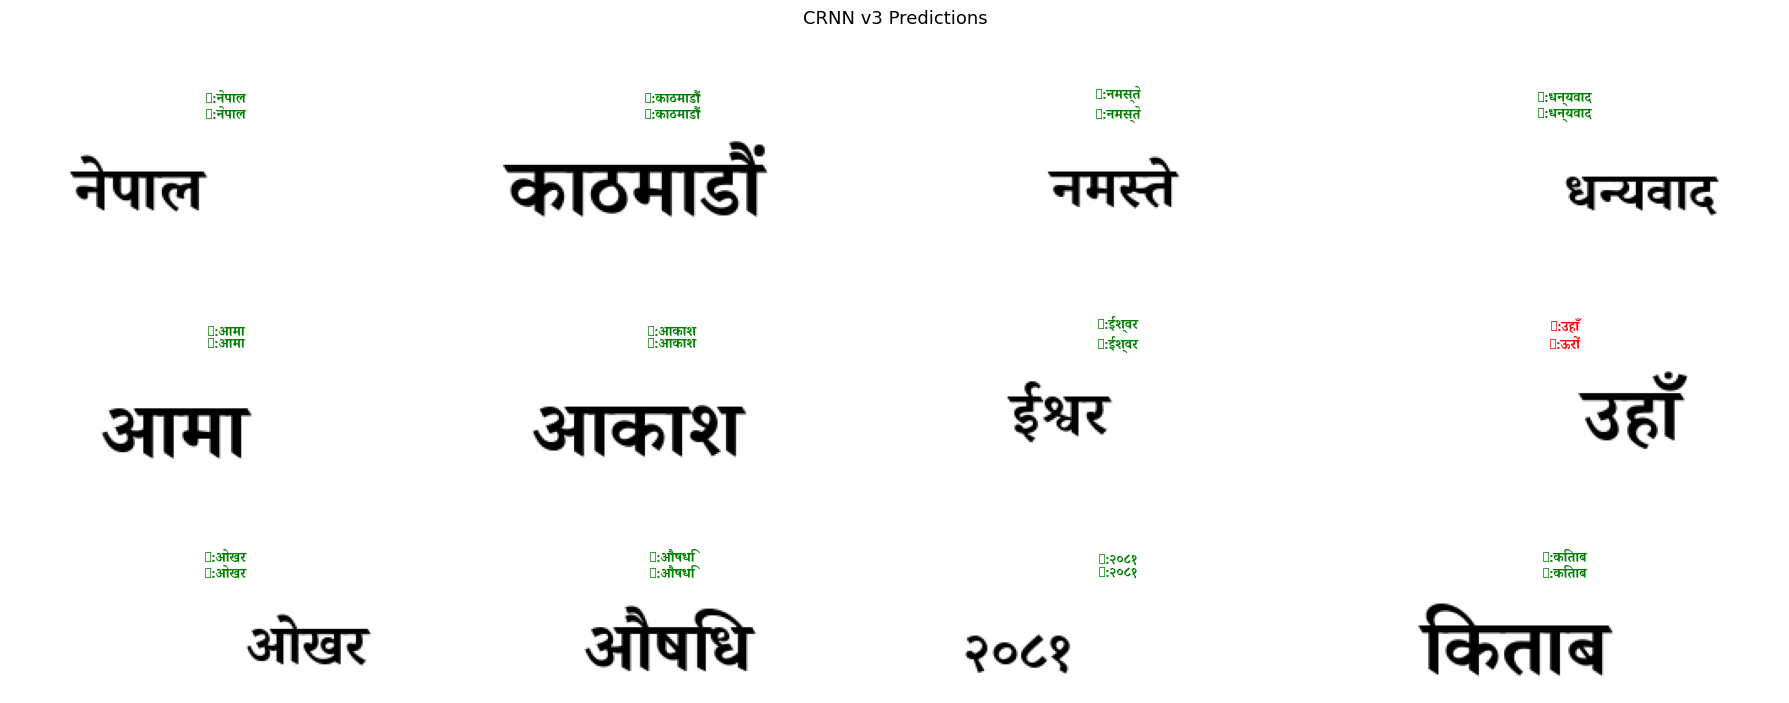


Accuracy: 11/12


In [13]:
# ── Test CRNN v3 ──────────────────────────────────────────────
model3.eval()

test_words = ['नेपाल', 'काठमाडौं', 'नमस्ते', 'धन्यवाद',
              'आमा', 'आकाश', 'ईश्वर', 'उहाँ',
              'ओखर', 'औषधि', '२०८१', 'किताब']

print("CRNN v3 Predictions:")
print("─" * 50)

correct_count = 0
fig, axes = plt.subplots(3, 4, figsize=(18, 8))

for i, word in enumerate(test_words):
    img   = generate_word_image(word)
    img_t = T.ToTensor()(img)
    img_t = T.Normalize((0.5,), (0.5,))(img_t)
    img_t = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        out  = model3(img_t)
        pred = ctc_decode(out[0], idx2char)

    correct = pred == word
    if correct:
        correct_count += 1
    symbol = "✓" if correct else "✗"
    print(f"{symbol} True: {word:15s} | Pred: {pred}")

    color = 'green' if correct else 'red'
    axes[i//4][i%4].imshow(img, cmap='gray')
    axes[i//4][i%4].set_title(f"T:{word}\nP:{pred}",
                               fontproperties=prop, fontsize=10, color=color)
    axes[i//4][i%4].axis('off')

plt.suptitle('CRNN v3 Predictions', fontsize=13)
plt.tight_layout()
plt.show()
print(f"\nAccuracy: {correct_count}/{len(test_words)}")

In [14]:
# ── Add more chandrabindu words and train longer ──────────────
CHANDRABINDU_WORDS = [
    'उहाँ', 'यहाँ', 'त्यहाँ', 'कहाँ', 'जहाँ',
    'हाँ', 'हुँदा', 'हुँछ', 'भुँडी', 'घाँटी',
    'आँखा', 'आँसु', 'आँधी', 'ठाँउ', 'ठाउँ',
    'गाँउ', 'गाउँ', 'खाँचो', 'साँचो', 'साँझ',
    'सुँघ्नु', 'भाँचिनु', 'नाँघ्नु', 'छाँट्नु',
]

NEPALI_WORDS_V3 = NEPALI_WORDS_V2 + CHANDRABINDU_WORDS

# Verify all encodable
all_ok = True
for word in NEPALI_WORDS_V3:
    missing = [ch for ch in word if ch not in char2idx]
    if missing:
        print(f"Missing in {word}: {missing}")
        all_ok = False

print(f"Total words: {len(NEPALI_WORDS_V3)}")
if all_ok:
    print("All encodable!")

# Retrain with more epochs
train_ds4 = CRNNDataset(NEPALI_WORDS_V3, n_samples=12000)
train_loader4 = DataLoader(train_ds4, batch_size=32, shuffle=True,
                           collate_fn=collate_fn, num_workers=0)

model4    = CRNN(num_classes=len(CHARS)).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.Adam(model4.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 30
for epoch in range(EPOCHS):
    model4.train()
    total_loss = 0
    for imgs, labels, lengths in train_loader4:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        out        = model4(imgs)
        out_ctc    = out.permute(1, 0, 2)
        input_lens = torch.full((imgs.size(0),), out.size(1), dtype=torch.long)
        flat_labels = []
        flat_lens   = []
        for i in range(labels.size(0)):
            l = labels[i][:lengths[i]]
            flat_labels.append(l)
            flat_lens.append(lengths[i].item())
        flat_labels = torch.cat(flat_labels)
        flat_lens   = torch.tensor(flat_lens, dtype=torch.long)
        loss = criterion(out_ctc, flat_labels, input_lens, flat_lens)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model4.parameters(), 5)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {total_loss/len(train_loader4):.4f}")

print("\nSaving...")
torch.save(model4.state_dict(), '/home/kulraj/nepali_ocr/models/crnn_nepali_v4.pth')
print("Saved!")

Total words: 171
All encodable!
Epoch 01/30 | Loss: 3.9584
Epoch 02/30 | Loss: 1.8243
Epoch 03/30 | Loss: 0.3293
Epoch 04/30 | Loss: 0.0336
Epoch 05/30 | Loss: 0.0601
Epoch 06/30 | Loss: 0.0076
Epoch 07/30 | Loss: 0.0045
Epoch 08/30 | Loss: 0.0034
Epoch 09/30 | Loss: 0.0025
Epoch 10/30 | Loss: 0.0019
Epoch 11/30 | Loss: 0.0014
Epoch 12/30 | Loss: 0.0012
Epoch 13/30 | Loss: 0.0010
Epoch 14/30 | Loss: 0.0009
Epoch 15/30 | Loss: 0.0008
Epoch 16/30 | Loss: 0.0007
Epoch 17/30 | Loss: 0.0006
Epoch 18/30 | Loss: 0.0006
Epoch 19/30 | Loss: 0.0005
Epoch 20/30 | Loss: 0.0005
Epoch 21/30 | Loss: 0.0004
Epoch 22/30 | Loss: 0.0004
Epoch 23/30 | Loss: 0.0004
Epoch 24/30 | Loss: 0.0003
Epoch 25/30 | Loss: 0.0003
Epoch 26/30 | Loss: 0.0003
Epoch 27/30 | Loss: 0.0003
Epoch 28/30 | Loss: 0.0002
Epoch 29/30 | Loss: 0.0002
Epoch 30/30 | Loss: 0.0002

Saving...
Saved!


CRNN v4 Predictions:
──────────────────────────────────────────────────
✓ True: नेपाल           | Pred: नेपाल
✓ True: काठमाडौं        | Pred: काठमाडौं
✓ True: नमस्ते          | Pred: नमस्ते
✓ True: धन्यवाद         | Pred: धन्यवाद
✓ True: आमा             | Pred: आमा
✓ True: आकाश            | Pred: आकाश
✓ True: ईश्वर           | Pred: ईश्वर
✓ True: उहाँ            | Pred: उहाँ
✓ True: ओखर             | Pred: ओखर
✓ True: औषधि            | Pred: औषधि
✓ True: २०८१            | Pred: २०८१
✓ True: किताब           | Pred: किताब


/tmp/ipykernel_30174/3439788341.py:37: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/3439788341.py:37: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/3439788341.py:37: UserWarning: Glyph 84 (T) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_30174/3439788341.py:37: UserWarning: Glyph 80 (P) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()


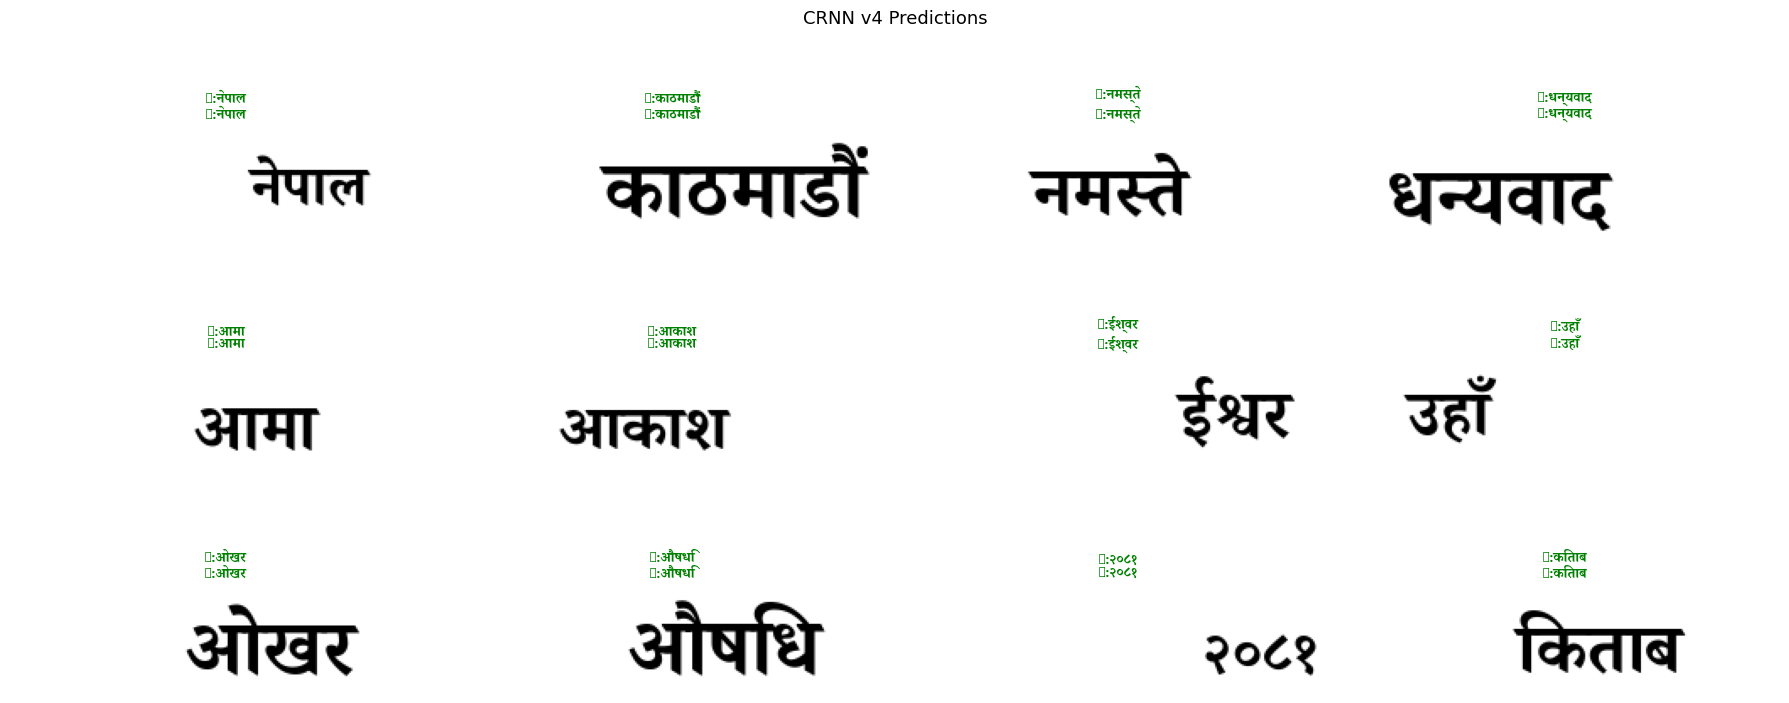


Accuracy: 12/12


In [15]:
# ── Test CRNN v4 ──────────────────────────────────────────────
model4.eval()

test_words = ['नेपाल', 'काठमाडौं', 'नमस्ते', 'धन्यवाद',
              'आमा', 'आकाश', 'ईश्वर', 'उहाँ',
              'ओखर', 'औषधि', '२०८१', 'किताब']

print("CRNN v4 Predictions:")
print("─" * 50)

correct_count = 0
fig, axes = plt.subplots(3, 4, figsize=(18, 8))

for i, word in enumerate(test_words):
    img   = generate_word_image(word)
    img_t = T.ToTensor()(img)
    img_t = T.Normalize((0.5,), (0.5,))(img_t)
    img_t = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        out  = model4(img_t)
        pred = ctc_decode(out[0], idx2char)

    correct = pred == word
    if correct:
        correct_count += 1
    symbol = "✓" if correct else "✗"
    print(f"{symbol} True: {word:15s} | Pred: {pred}")

    color = 'green' if correct else 'red'
    axes[i//4][i%4].imshow(img, cmap='gray')
    axes[i//4][i%4].set_title(f"T:{word}\nP:{pred}",
                               fontproperties=prop, fontsize=10, color=color)
    axes[i//4][i%4].axis('off')

plt.suptitle('CRNN v4 Predictions', fontsize=13)
plt.tight_layout()
plt.show()
print(f"\nAccuracy: {correct_count}/{len(test_words)}")